<h1 align="center"> Baseline Models </h1>

<br>
<i> Import necessary libraries: <i>

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
import matplotlib.pyplot as plt
import sklearn.metrics as mx
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report

from src.optimise import capitalize_j, format_case_id

from imblearn.ensemble import BalancedRandomForestClassifier

from pybiomart import Server
import seaborn as sns

np.random.seed(2)

<i> Helper Functions: <i>

In [2]:
# def spearman_df_function(features, target, threshold):
#     feature_names = []
#     feature_correlations = []
    
#     column_names = features.columns.tolist()

#     for column in column_names:
#         corr, pval = spearmanr(features[column], target)
#         if (corr >= threshold):
#             feature_names.append(column)
#             feature_correlations.append(corr)

#     return feature_names, feature_correlations

def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold and pval < 0.05):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

def modelPerformance(confMat):
    TN = confMat[0, 0]
    TP = confMat[1, 1]
    FP = confMat[0, 1]
    FN = confMat[1, 0]
    prec = TP / (TP + FP)
    rec = TP / (TP + FN)
    spec = TN / (TN + FP)
    fpr = FP / (TN + FP)
    f1 = 2 * (prec * rec) / (prec + rec)
    acc = (TP + TN) / (TP + FP + TN + FN)
    return (acc, prec, rec, spec, fpr, f1)

def printPerformance(confMat):
    acc, prec, rec, spec, fpr, f1 = modelPerformance(confMat)
    print("Accuracy = " "%.4f" % acc)
    print("Precision = " "%.4f" % prec)
    print("Recall = " "%.4f" % rec)
    print("Specificity = " "%.4f" % spec)
    print("False positive rate = " "%.4f" % fpr)
    print("F1-score = " "%.4f" % f1)
    np.set_printoptions(precision=2)
    print("Confusion matrix (%):")
    print(confMat/np.sum(confMat)*100)

def proximityMatrix(mdl, X, normalize=True):      
    endNode = mdl.apply(X)
    nTrees = endNode.shape[1]
    n = X.shape[0]
    proxMat = np.zeros((n,n))
    for k in range(0, nTrees):
        a = endNode[:,k]
        proxMat += 1*np.equal.outer(a, a)
    if normalize:
        proxMat = proxMat / nTrees
    return proxMat

### Matching Samples for Analysis

In [3]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

df_merged_copy = df_merged

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [4]:
# Check length of both paired sample dataframes
print("Number of rows in paired radiomics samples:", df_merged2.shape[0])
print("Number of rows in paired RNA samples:", df_merged.shape[0])

Number of rows in paired radiomics samples: 36
Number of rows in paired RNA samples: 36


### Pair Images and RNA data

In [5]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

rna_paired_id_list = []
rad_paired_id_list = [] 

In [6]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    rna_paired_id_list.append(case_id2)
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  29


In [7]:
for index, row in df_merged2.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

                if (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    rad_paired_id_list.append(case_id2)
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  29


In [8]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rad)
print(f"Matching Images: ", flag2)

flag3 = (rna_paired_id_list == rad_paired_id_list)
print(f"Matching IDs: ", flag3)

Matching Diagnoses:  True
Matching Images:  True
Matching IDs:  True


In [9]:
# Create DataFrame for surgical matching
match_dict = {"image_name": image_filenames_rad, "ID": rad_paired_id_list, "SURGICAL": surgical_rad} 
match_df = pd.DataFrame(match_dict)
match_df

,image_name,ID,SURGICAL
0,12930_3.nii.gz,12930,B-S
1,13291_0010.nii.gz,13291,M-S
2,14023_3.nii.gz,14023,M-S
3,14056_3.nii.gz,14056,M-S
4,14654_3.nii.gz,14654,M-S
5,14024_2.nii.gz,14024,M-S
6,14984_0039.nii.gz,14984,M-S
7,16106_0022.nii.gz,16106,B-S
8,16134_0049.nii.gz,16134,M-S
9,16208_1.nii.gz,16208,B-S


### Get Unpaired Images and RNA Data 
(_validation_)

In [10]:
# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)
# Filter columns
surg_placeholder = df_radiomics["SURGICAL"]
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED
df_radiomics.insert(0, "SURGICAL", surg_placeholder)
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].str.strip() 
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["B-NS", "B-NS -->THEATRE"], "B-S")
df_radiomics["SURGICAL"] = df_radiomics["SURGICAL"].replace(["M-NS"], "M-S")
df_radiomics = df_radiomics.loc[df_radiomics["SURGICAL"] != "NS"]
df_radiomics["ID"] = df_radiomics["ID"].astype(str)

In [11]:
rad_paired_id_list_noj = list(map(lambda x: "26246" if x == "J630" else x, rad_paired_id_list))
df_unpaired_rad = df_radiomics[~df_radiomics["ID"].isin(rad_paired_id_list_noj)]
df_unpaired_rna = df_merged_copy[~df_merged_copy["CASE ID"].isin(rna_paired_id_list) & ~df_merged_copy["CASE ID2"].isin(rna_paired_id_list)]


In [12]:
# Check length of both unpaired sample dataframes
print("Number of rows in unpaired radiomics samples:", df_unpaired_rad.shape[0])
print("Number of rows in unpaired RNA samples:", df_unpaired_rna.shape[0])

Number of rows in unpaired radiomics samples: 547
Number of rows in unpaired RNA samples: 38


In [13]:
check1 = df_unpaired_rad["ID"].to_list()
check2 = rad_paired_id_list
set(check1) & set(check2)

set()

In [14]:
check1 = df_unpaired_rna["CASE ID"].to_list() + df_unpaired_rna["CASE ID2"].to_list()
check2 = rna_paired_id_list
set(check1) & set(check2)

set()

In [15]:
# Create DataFrame for surgical matching
match_rad_dict = {"CASE ID": df_unpaired_rad["ID"].astype("int64"), "SURGICAL": df_unpaired_rad["SURGICAL"]} 
match_rad_df = pd.DataFrame(match_rad_dict)
match_rad_df

,CASE ID,SURGICAL
0,11935,B-S
1,12041,B-S
2,12165,B-S
3,12287,M-S
4,12665,M-S
...,...,...
572,756,B-S
573,757,B-S
574,759,B-S
575,760,M-S


In [16]:
# Create DataFrame for surgical matching
match_rna_dict = {"CASE ID": df_unpaired_rna["CASE ID"], "CASE ID2": df_unpaired_rna["CASE ID2"], "SURGICAL": df_unpaired_rna["SURGICAL"]} 
match_rna_df = pd.DataFrame(match_rna_dict)
match_rna_df

,CASE ID,CASE ID2,SURGICAL
0,12930,NaN,B-S
1,13291,NaN,M-S
2,13750,NaN,M-S
3,14023,NaN,M-S
4,14056,NaN,M-S
5,14654,NaN,M-S
6,14024,NaN,M-S
7,14984,NaN,M-S
8,16106,NaN,B-S
9,16134,NaN,M-S


### Train-test Split

In [17]:
# Convert to DataFrame
rad_data_filtered = pd.DataFrame(rad_data_filtered)
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [18]:
# Step 1: Split into train and test sets
rad_train, rad_test, rna_train, rna_test, surg_train, surg_test, img_train, img_test = train_test_split(rad_data_filtered, rna_data_filtered, surgical_rad, image_filenames_rad, test_size=0.2, random_state=2)

In [19]:
# Convert back to DataFrame
rad_train = pd.DataFrame(rad_train, columns=rad_data_filtered.columns)
rad_test = pd.DataFrame(rad_test, columns=rad_data_filtered.columns)
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [20]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of radiomics samples: ", rad_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  23
Number of radiomics samples:  23
Number of image filenames:  23
Number of diagnoses:  23
Image filenames:  ['24903_0011.nii.gz', '14984_0039.nii.gz', '14056_3.nii.gz', '25962_0006.nii.gz', '26604_0007.nii.gz', '26428_0020.nii.gz', '187867.nii.gz', '14654_3.nii.gz', '16439_0004.nii.gz', '14024_2.nii.gz', '25970_2.nii.gz', '25607_0005.nii.gz', '14023_3.nii.gz', '16106_0022.nii.gz', '26425_-3.nii.gz', '26417_1.nii.gz', '25827_0006.nii.gz', '18638_0037.nii.gz', 'J630_0008.nii.gz', '26379_5.nii.gz', '18853_0020.nii.gz', '24354_0019.nii.gz', '16134_0049.nii.gz']
Diagnoses:  ['M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


In [21]:
print(f"Number of RNA samples: ", rna_test.shape[0])
print(f"Number of radiomics samples: ", rad_test.shape[0])
print(f"Number of image filenames: ", len(img_test))
print(f"Number of diagnoses: ", len(surg_test))
print(f"Image filenames: ", img_test)
print(f"Diagnoses: ", surg_test)

Number of RNA samples:  6
Number of radiomics samples:  6
Number of image filenames:  6
Number of diagnoses:  6
Image filenames:  ['13291_0010.nii.gz', '12930_3.nii.gz', '18852_0009.nii.gz', '16208_1.nii.gz', '25961_2.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S']


# Radiomics Model

### Radiomics Tabular Data

In [22]:
# Scale radiomics sample counts
scaler_rad = StandardScaler()
rad_train_df = pd.DataFrame(scaler_rad.fit_transform(rad_train), columns=rad_data_filtered.columns)
rad_train_df.insert(0, "SURGICAL", surg_train)

rad_test_df = pd.DataFrame(scaler_rad.transform(rad_test), columns=rad_data_filtered.columns)
rad_test_df.insert(0, "SURGICAL", surg_test)

In [23]:
# Filter features selected using Spearman Rho
rad_all = rad_train_df.drop(["SURGICAL"], axis=1)
rad_class_cat = pd.Categorical(rad_train_df["SURGICAL"].astype("category")).codes
rad_feature_names, rad_feature_correlations = spearman_df_function(rad_all, rad_class_cat, 0.3)

/tmp/ipykernel_54782/4173520191.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [24]:
spearman_df = pd.DataFrame(
    {
        "Features": rad_feature_names,
        "Correlations": rad_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,GLSZM_ZoneHiGl_4gl,0.467099
1,GLCM_Varian_8gl,0.428174
2,GLCM_Varian_32gl,0.428174
3,GLCM_Varian_64gl,0.428174
4,GLCM_Varian_256gl,0.428174
5,GLSZM_ZoneHiGl_LLL_4gl,0.467099
6,NGTDM_Contra_LLL_8gl,0.428174
7,GLSZM_SzNonUnif_LLL_32gl,0.467099
8,GLSZM_SzVarianc_LLL_32gl,0.525487
9,GLSZM_SzNonUnif_LLL_64gl,0.428174


In [25]:
# Store spearman features
spearman_rad = spearman_df["Features"].to_list()

In [26]:
# Seperating out the features
X_train_rad = rad_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_train_rad = X_train_rad.loc[:, X_train_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_train_rad = rad_train_df[["SURGICAL"]]

### Fit Random Forest Model

In [27]:
# Set the random state for reproducibility
fit_rf_rad = BalancedRandomForestClassifier(n_estimators=1000, 
                                    random_state=2)

In [ ]:
# Hyperparameter optimisation
param_dist = {"bootstrap": [True, False],
    "max_depth": [80, 90, 100, 110],
    "max_features": ["sqrt", "log2", 0.5, 0.7, None],
    "criterion": ["gini", "entropy"]}

cv_rf_rad = GridSearchCV(fit_rf_rad, cv=3, param_grid=param_dist, verbose=3)

In [ ]:
cv_rf_rad.fit(X_train_rad, y_train_rad.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_rad.best_params_)

`Best Parameters using grid search: 
 {'bootstrap': False, 'criterion': 'gini', 'max_depth': 80, 'max_features': 'sqrt'}`

In [28]:
# Set best parameters given by grid search
fit_rf_rad.set_params(bootstrap = True,
                        criterion = "gini",
                        max_depth = 80,
                        max_features = "sqrt")

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=1000,
                               random_state=2)

### Out of Bag Error Rate

In [ ]:
fit_rf_rad.set_params(bootstrap = True,
                        n_estimators=100,
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_rad.set_params(n_estimators=i)
    fit_rf_rad.fit(X_train_rad, y_train_rad.values.ravel())

    oob_error = 1 - fit_rf_rad.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(600, 1000)
plt.plot(num_estimators, oob_error)
plt.axhline(0.15, color="red", linestyle="--")
plt.axhline(0.11, color="red", linestyle="--")
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

`n_estimators` = 900

### Build Random Forest Model Using Best Parameters

In [29]:
# Create the classifier
fit_rf_rad.set_params(bootstrap = True,
                        n_estimators = 900, 
                        max_depth = 80,
                        max_features = "sqrt",
                        criterion= "gini",
                        oob_score = True,
                        random_state = 2)

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=900,
                               oob_score=True, random_state=2)

In [30]:
# Fit the model to the training set
fit_rf_rad.fit(X_train_rad, y_train_rad)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=900,
                               oob_score=True, random_state=2)

### Visualise Feature Importance

In [31]:
# Feature scores
feature_scores = pd.Series(fit_rf_rad.feature_importances_, index=X_train_rad.columns).sort_values(ascending=True)
feature_scores = feature_scores[feature_scores > 0]

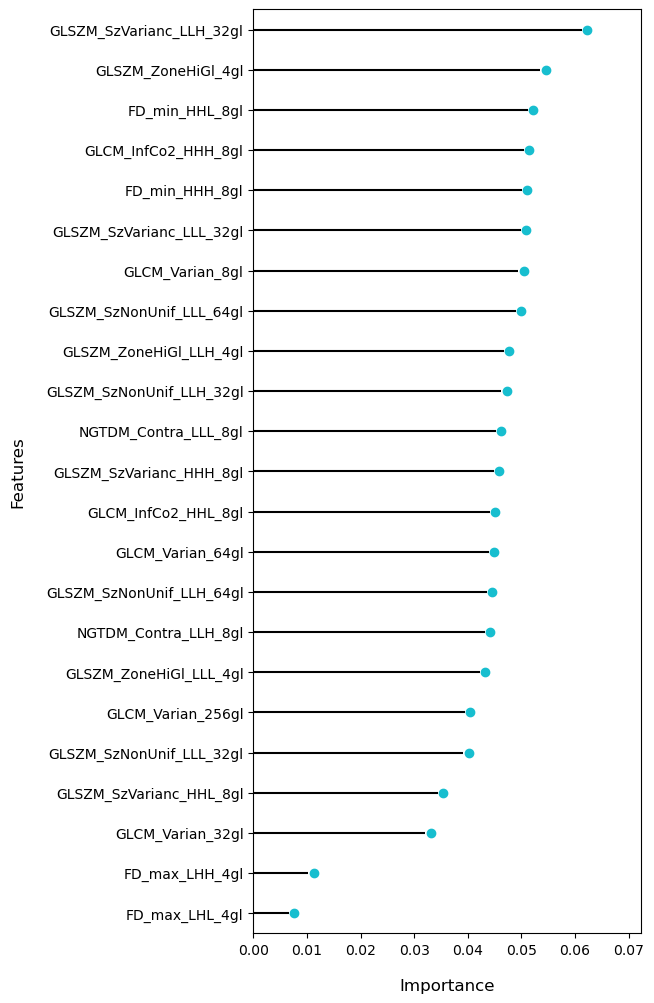

In [32]:
fig, ax = plt.subplots(figsize=(5, 12))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

ax.scatter(x=feature_scores, y=feature_scores.index, color="#17BECF")
miny, nexty, *_, maxy = ax.get_yticks()
eps = (nexty - miny) / 2 
ax.set_ylim(miny-eps, maxy+eps)
ax.set_xlim(0, max(feature_scores+0.01))
for x, y in zip(feature_scores, feature_scores.index):
    plt.hlines(y = y, xmin = 0, xmax = x-0.001, color="black") 
ax.tick_params(axis="both", which="major", labelsize=10)
ax.set_ylabel("Features", fontsize=12, labelpad=15)
ax.set_xlabel("Importance", fontsize=12, labelpad=15)

plt.show()


### Evaluate Model

#### Train

In [33]:
# Train 
y_train_rad_pred = pd.DataFrame(np.argmax(fit_rf_rad.oob_decision_function_,axis=1))
y_train_rad_pred.columns = ["SURGICAL"]
y_train_rad_pred["SURGICAL"] = y_train_rad_pred["SURGICAL"].map({1: "M-S", 0: "B-S"})
cmat = mx.confusion_matrix(y_train_rad, y_train_rad_pred)

In [34]:
printPerformance(cmat)

Accuracy = 0.9130
Precision = 1.0000
Recall = 0.9000
Specificity = 1.0000
False positive rate = 0.0000
F1-score = 0.9474
Confusion matrix (%):
[[13.04  0.  ]
 [ 8.7  78.26]]


In [35]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.087


In [36]:
# Print classification report for model
print(classification_report(y_train_rad, y_train_rad_pred))

              precision    recall  f1-score   support

         B-S       0.60      1.00      0.75         3
         M-S       1.00      0.90      0.95        20

    accuracy                           0.91        23
   macro avg       0.80      0.95      0.85        23
weighted avg       0.95      0.91      0.92        23



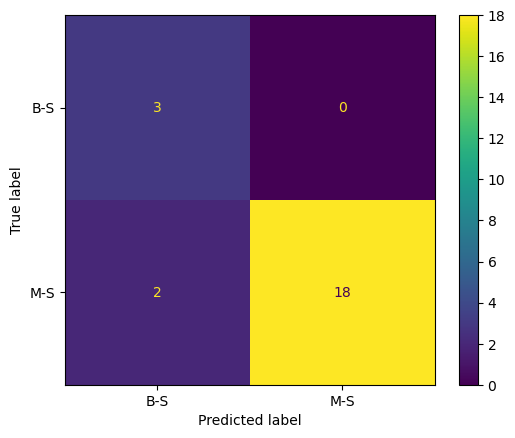

In [37]:
cm = confusion_matrix(y_train_rad, y_train_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

#### Test

In [38]:
# Test

# Seperating out the features
X_test_rad = rad_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_test_rad = X_test_rad.loc[:, X_test_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_test_rad = rad_test_df[["SURGICAL"]]

y_test_rad_pred = fit_rf_rad.predict(X_test_rad)
cmat = mx.confusion_matrix(y_test_rad, y_test_rad_pred)

In [39]:
printPerformance(cmat)

Accuracy = 0.5000
Precision = 0.5000
Recall = 0.6667
Specificity = 0.3333
False positive rate = 0.6667
F1-score = 0.5714
Confusion matrix (%):
[[16.67 33.33]
 [16.67 33.33]]


In [40]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.087


In [41]:
# Print classification report for model
print(classification_report(y_test_rad, y_test_rad_pred))

              precision    recall  f1-score   support

         B-S       0.50      0.33      0.40         3
         M-S       0.50      0.67      0.57         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



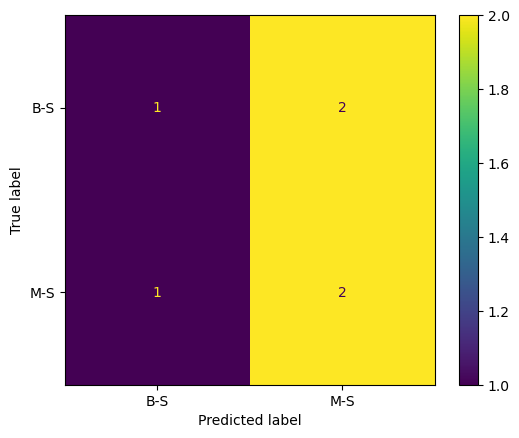

In [42]:
cm = confusion_matrix(y_test_rad, y_test_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

#### Validation (Unpaired Data)

In [43]:
rad_col_list = list(rad_train.columns.values)
rad_val = df_unpaired_rad.loc[:, df_unpaired_rad.columns.isin(rad_col_list)]
surg_val = df_unpaired_rad["SURGICAL"].to_list()

# Scale radiomics sample counts
rad_val_df = pd.DataFrame(scaler_rad.transform(rad_val), columns=rad_data_filtered.columns)
rad_val_df.insert(0, "SURGICAL", surg_val)


In [44]:
# Validation

# Seperating out the features
X_val_rad = rad_val_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_val_rad = X_val_rad.loc[:, X_val_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_val_rad = rad_val_df[["SURGICAL"]]

y_val_rad_pred = fit_rf_rad.predict(X_val_rad)
cmat = mx.confusion_matrix(y_val_rad, y_val_rad_pred)

In [45]:
printPerformance(cmat)

Accuracy = 0.5558
Precision = 0.2624
Recall = 0.6789
Specificity = 0.5251
False positive rate = 0.4749
F1-score = 0.3785
Confusion matrix (%):
[[42.05 38.03]
 [ 6.4  13.53]]


In [46]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.087


In [47]:
# Print classification report for model
print(classification_report(y_val_rad, y_val_rad_pred))

              precision    recall  f1-score   support

         B-S       0.87      0.53      0.65       438
         M-S       0.26      0.68      0.38       109

    accuracy                           0.56       547
   macro avg       0.57      0.60      0.52       547
weighted avg       0.75      0.56      0.60       547



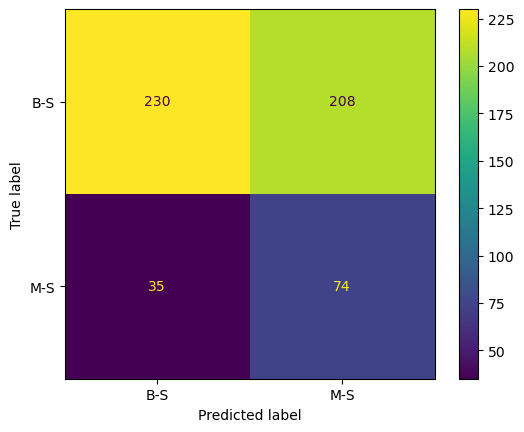

In [48]:
cm = confusion_matrix(y_val_rad, y_val_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

### Plot the ROC Curve

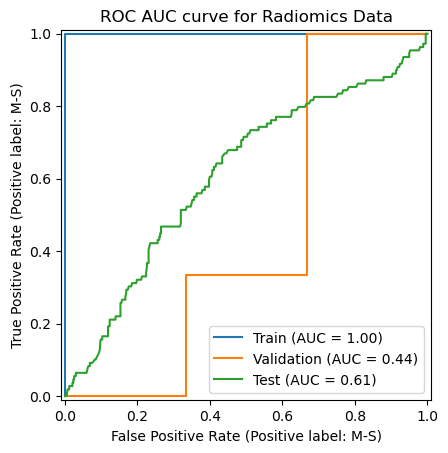

In [49]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_train_rad, y_train_rad, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_test_rad, y_test_rad, pos_label='M-S', ax = disp.ax_, name="Validation")

# Validation data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_val_rad, y_val_rad, pos_label='M-S', ax = disp.ax_, name="Test")

disp.ax_.set_title("ROC AUC curve for Radiomics Data");

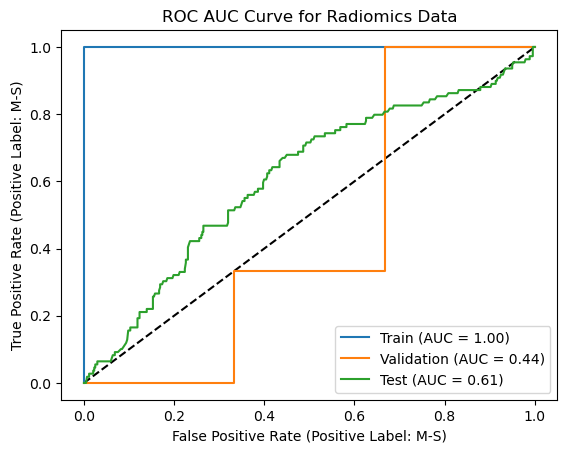

In [50]:
# Train
y_pred_prob1 = fit_rf_rad.predict_proba(X_train_rad)[:, 1]
fpr1, tpr1, thresholds1 = roc_curve(y_train_rad, y_pred_prob1, pos_label="M-S")
auc1 = roc_auc_score(y_train_rad, y_pred_prob1)

# Test
y_pred_prob2 = fit_rf_rad.predict_proba(X_test_rad)[:, 1]
fpr2, tpr2, thresholds2 = roc_curve(y_test_rad, y_pred_prob2, pos_label="M-S")
auc2 = roc_auc_score(y_test_rad, y_pred_prob2)

# Validate
y_pred_prob3 = fit_rf_rad.predict_proba(X_val_rad)[:, 1]
fpr3, tpr3, thresholds3 = roc_curve(y_val_rad, y_pred_prob3, pos_label="M-S")
auc3 = roc_auc_score(y_val_rad, y_pred_prob3)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr1, tpr1, label="Train (AUC = %0.2f)" % auc1)
plt.plot(fpr2, tpr2, label="Validation (AUC = %0.2f)" % auc2)
plt.plot(fpr3, tpr3, label="Test (AUC = %0.2f)" % auc3)

plt.legend()
plt.xlabel("False Positive Rate (Positive Label: M-S)")
plt.ylabel("True Positive Rate (Positive Label: M-S)")
plt.title('ROC AUC Curve for Radiomics Data')
plt.show()

# RNA Model

### RNA Tabular Data

In [51]:
# Scale RNA sample counts
scaler_rna = StandardScaler()
rna_train_df = pd.DataFrame(scaler_rna.fit_transform(rna_train), columns=rna_data_filtered.columns)
rna_train_df.insert(0, "SURGICAL", surg_train)

rna_test_df = pd.DataFrame(scaler_rna.transform(rna_test), columns=rna_data_filtered.columns)
rna_test_df.insert(0, "SURGICAL", surg_test)

In [52]:
# Filter features selected using Spearman Rho
rna_all = rna_train_df.drop(["SURGICAL"], axis=1)
rna_class_cat = pd.Categorical(rna_train_df["SURGICAL"].astype("category")).codes
rna_feature_names, rna_feature_correlations = spearman_df_function(rna_all, rna_class_cat, 0.50)

/tmp/ipykernel_54782/4173520191.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [53]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_feature_names,
        "Correlations": rna_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,ENSG00000189280,0.558978
1,ENSG00000163873,0.536678
2,ENSG00000143185,0.500767
3,ENSG00000162782,0.506525
4,ENSG00000197472,0.528498
...,...,...
240,ENSG00000161091,0.506024
241,ENSG00000225335,0.545354
242,ENSG00000242114,0.525487
243,ENSG00000128218,0.557859


In [54]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

In [55]:
# Seperating out the features
X_train_rna = rna_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_train_rna = X_train_rna.loc[:, X_train_rna.columns.isin(spearman_rna)]
# Seperating out the target
y_train_rna = rna_train_df[["SURGICAL"]]

### Fit Random Forest Model

In [56]:
# Set the random state for reproducibility
fit_rf_rna = BalancedRandomForestClassifier(n_estimators=1000, 
                                    random_state=2)

In [ ]:
# Hyperparameter optimisation
param_dist = {"bootstrap": [True, False],
    "max_depth": [80, 90, 100, 110],
    "max_features": ["sqrt", "log2", 0.5, 0.7, None],
    "criterion": ["gini", "entropy"]}

cv_rf_rna = GridSearchCV(fit_rf_rna, cv=3, param_grid=param_dist, verbose=3)

In [ ]:
cv_rf_rna.fit(X_train_rna, y_train_rna.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_rna.best_params_)

`Best Parameters using grid search: 
 {'bootstrap': False, 'criterion': 'gini', 'max_depth': 80, 'max_features': 'sqrt'}`

In [57]:
# Set best parameters given by grid search
fit_rf_rna.set_params(bootstrap = True,
                        criterion = "gini",
                        max_depth = 80,
                        max_features = "sqrt")

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=1000,
                               random_state=2)

### Out of Bag Error Rate

In [ ]:
fit_rf_rna.set_params(n_estimators=100,
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_rna.set_params(n_estimators=i)
    fit_rf_rna.fit(X_train_rna, y_train_rna.values.ravel())

    oob_error = 1 - fit_rf_rna.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(100, 300)
plt.plot(num_estimators, oob_error)
plt.axhline(0.06, color="red", linestyle="--")
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

`n_estimators` = 250

### Build Random Forest Model Using Best Parameters

In [58]:
# Create the classifier
fit_rf_rna.set_params(bootstrap = True,
                        n_estimators = 250, 
                        max_depth = 80,
                        max_features = "sqrt",
                        criterion= "gini",
                        oob_score = True,
                        random_state = 2)

BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=250,
                               oob_score=True, random_state=2)

In [59]:
# Fit the model to the training set
fit_rf_rna.fit(X_train_rna, y_train_rna)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


BalancedRandomForestClassifier(bootstrap=True, max_depth=80, n_estimators=250,
                               oob_score=True, random_state=2)

### Visualise Feature Importance

In [60]:
# Feature scores
feature_scores = pd.Series(fit_rf_rna.feature_importances_, index=X_train_rna.columns).sort_values(ascending=True)
feature_scores = feature_scores[feature_scores > 0]

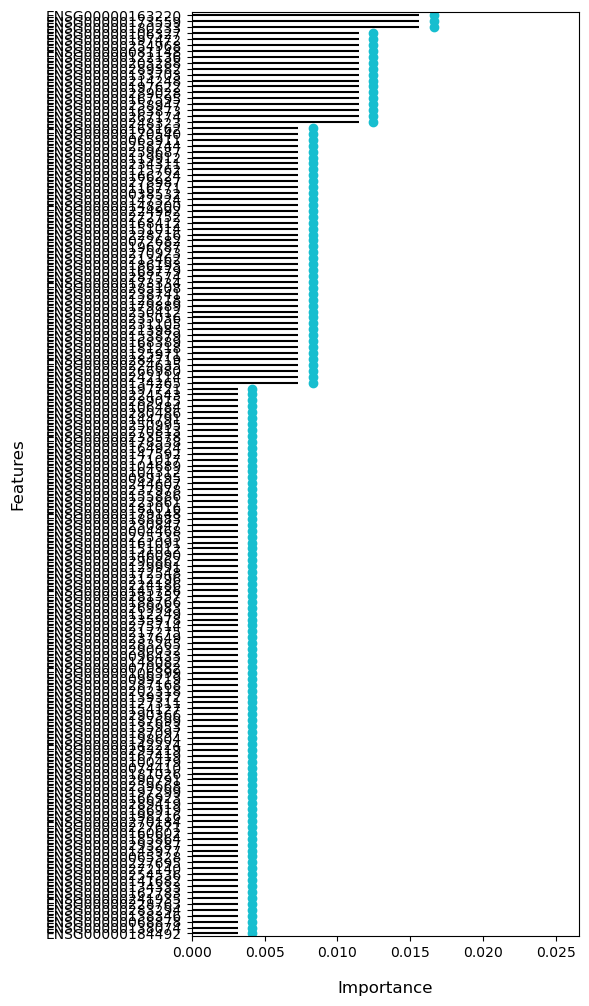

In [61]:
fig, ax = plt.subplots(figsize=(5, 12))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

ax.scatter(x=feature_scores, y=feature_scores.index, color="#17BECF")
miny, nexty, *_, maxy = ax.get_yticks()
eps = (nexty - miny) / 2 
ax.set_ylim(miny-eps, maxy+eps)
ax.set_xlim(0, max(feature_scores+0.01))
for x, y in zip(feature_scores, feature_scores.index):
    plt.hlines(y = y, xmin = 0, xmax = x-0.001, color="black") 
ax.tick_params(axis="both", which="major", labelsize=10)
ax.set_ylabel("Features", fontsize=12, labelpad=15)
ax.set_xlabel("Importance", fontsize=12, labelpad=15)

plt.show()

### Evaluate Model

#### Train

In [62]:
# Train 
y_train_rna_pred = pd.DataFrame(np.argmax(fit_rf_rna.oob_decision_function_,axis=1))
y_train_rna_pred.columns = ["SURGICAL"]
y_train_rna_pred["SURGICAL"] = y_train_rna_pred["SURGICAL"].map({1: "M-S", 0: "B-S"})
cmat = mx.confusion_matrix(y_train_rna, y_train_rna_pred)

In [63]:
printPerformance(cmat)

Accuracy = 0.9565
Precision = 1.0000
Recall = 0.9500
Specificity = 1.0000
False positive rate = 0.0000
F1-score = 0.9744
Confusion matrix (%):
[[13.04  0.  ]
 [ 4.35 82.61]]


In [64]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.087


In [65]:
# Print classification report for model
print(classification_report(y_train_rna, y_train_rna_pred))

              precision    recall  f1-score   support

         B-S       0.75      1.00      0.86         3
         M-S       1.00      0.95      0.97        20

    accuracy                           0.96        23
   macro avg       0.88      0.97      0.92        23
weighted avg       0.97      0.96      0.96        23



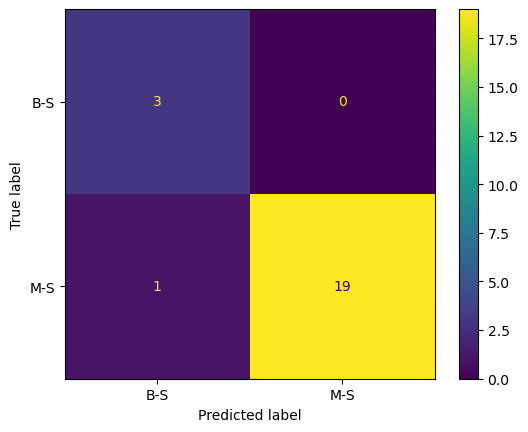

In [66]:
cm = confusion_matrix(y_train_rna, y_train_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

#### Test

In [67]:
# Test

# Seperating out the features
X_test_rna = rna_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_test_rna = X_test_rna.loc[:, X_test_rna.columns.isin(spearman_rna)]
# Seperating out the target
y_test_rna = rna_test_df[["SURGICAL"]]

y_test_rna_pred = fit_rf_rna.predict(X_test_rna)
cmat = mx.confusion_matrix(y_test_rna, y_test_rna_pred)

In [68]:
printPerformance(cmat)

Accuracy = 1.0000
Precision = 1.0000
Recall = 1.0000
Specificity = 1.0000
False positive rate = 0.0000
F1-score = 1.0000
Confusion matrix (%):
[[50.  0.]
 [ 0. 50.]]


In [69]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.087


In [70]:
# Print classification report for model
print(classification_report(y_test_rna, y_test_rna_pred))

              precision    recall  f1-score   support

         B-S       1.00      1.00      1.00         3
         M-S       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



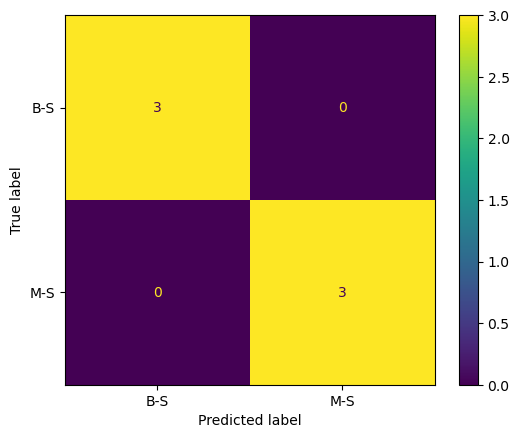

In [71]:
cm = confusion_matrix(y_test_rna, y_test_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

#### Validation (Unpaired Data)

In [72]:
rna_col_list = list(rna_train.columns.values)
rna_val = df_unpaired_rna.loc[:, df_unpaired_rna.columns.isin(rna_col_list)]
surg_val = df_unpaired_rna["SURGICAL"].to_list()

# Scale RNA sample counts
rna_val_df = pd.DataFrame(scaler_rna.transform(rna_val), columns=rna_data_filtered.columns)
rna_val_df.insert(0, "SURGICAL", surg_val)

In [73]:
# Validation

# Seperating out the features
X_val_rna = rna_val_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_val_rna = X_val_rna.loc[:, X_val_rna.columns.isin(spearman_rna)]
# Seperating out the target
y_val_rna = rna_val_df[["SURGICAL"]]

y_val_rna_pred = fit_rf_rna.predict(X_val_rna)
cmat = mx.confusion_matrix(y_val_rna, y_val_rna_pred)

In [74]:
printPerformance(cmat)

Accuracy = 0.9474
Precision = 1.0000
Recall = 0.9375
Specificity = 1.0000
False positive rate = 0.0000
F1-score = 0.9677
Confusion matrix (%):
[[15.79  0.  ]
 [ 5.26 78.95]]


In [75]:
# Obtain the OOB error 
oob_error = 1 - fit_rf_rad.oob_score_ 
# Print the OOB error 
print(f'OOB error: {oob_error:.3f}') 

OOB error: 0.087


In [76]:
# Print classification report for model
print(classification_report(y_val_rna, y_val_rna_pred))

              precision    recall  f1-score   support

         B-S       0.75      1.00      0.86         6
         M-S       1.00      0.94      0.97        32

    accuracy                           0.95        38
   macro avg       0.88      0.97      0.91        38
weighted avg       0.96      0.95      0.95        38



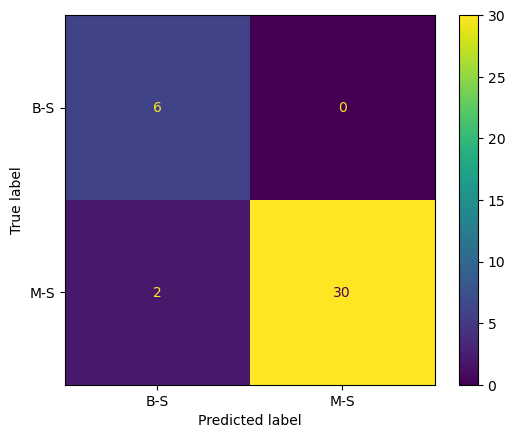

In [77]:
cm = confusion_matrix(y_val_rna, y_val_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

### Plot the ROC Curve

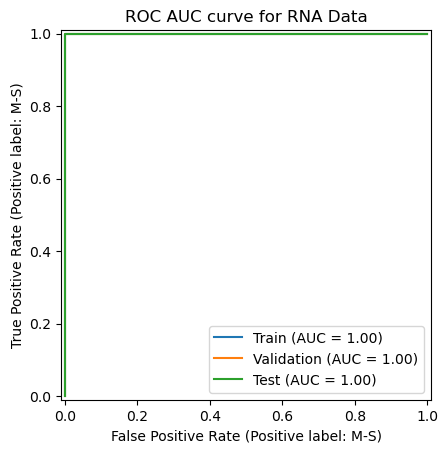

In [78]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_train_rna, y_train_rna, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_test_rna, y_test_rna, pos_label='M-S', ax = disp.ax_, name="Validation")

# Validation data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_val_rna, y_val_rna, pos_label='M-S', ax = disp.ax_, name="Test")

disp.ax_.set_title("ROC AUC curve for RNA Data");

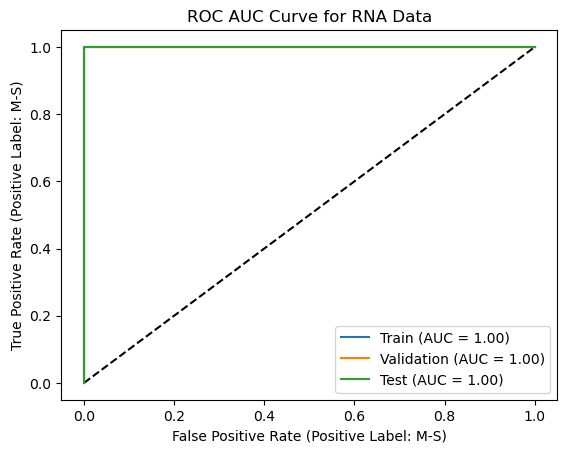

In [79]:
# Train
y_pred_prob1 = fit_rf_rna.predict_proba(X_train_rna)[:, 1]
fpr1, tpr1, thresholds1 = roc_curve(y_train_rna, y_pred_prob1, pos_label="M-S")
auc1 = roc_auc_score(y_train_rna, y_pred_prob1)

# Test
y_pred_prob2 = fit_rf_rna.predict_proba(X_test_rna)[:, 1]
fpr2, tpr2, thresholds2 = roc_curve(y_test_rna, y_pred_prob2, pos_label="M-S")
auc2 = roc_auc_score(y_test_rna, y_pred_prob2)

# Validate
y_pred_prob3 = fit_rf_rna.predict_proba(X_val_rna)[:, 1]
fpr3, tpr3, thresholds3 = roc_curve(y_val_rna, y_pred_prob3, pos_label="M-S")
auc3 = roc_auc_score(y_val_rna, y_pred_prob3)

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr1, tpr1, label="Train (AUC = %0.2f)" % auc1)
plt.plot(fpr2, tpr2, label="Validation (AUC = %0.2f)" % auc2)
plt.plot(fpr3, tpr3, label="Test (AUC = %0.2f)" % auc3)

plt.legend()
plt.xlabel("False Positive Rate (Positive Label: M-S)")
plt.ylabel("True Positive Rate (Positive Label: M-S)")
plt.title('ROC AUC Curve for RNA Data')
plt.show()

### Visualise Feature Importance

In [81]:
# Connect to Biomart server
server = Server(host="http://www.ensembl.org")
# Retrieving a ensembl genes mart
mart = server["ENSEMBL_MART_ENSEMBL"]
# Select homosapiens dataset
dataset = mart["hsapiens_gene_ensembl"]
# Retrieve the gene stable IDS and gene names from biomart
biomart_df = dataset.query(attributes=["ensembl_gene_id", "external_gene_name"])
biomart_df.head()

,Gene stable ID,Gene name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [82]:
X_train_rna_renamed = X_train_rna.copy(deep=True)

# Convert biomart_df to dictionary 
biomart_map = biomart_df.set_index("Gene name")
dict_genes = biomart_map["Gene stable ID"].to_dict()

# Convert ensmbl IDS to gene names
ensembl_ids_list = list(X_train_rna_renamed.columns)
gene_names = {v:k for k, v in dict_genes.items()}
genes_correct = [gene_names.get(item, item)  for item in ensembl_ids_list]

# Rename columns for RNA counts dataframe
X_train_rna_renamed.columns = genes_correct
X_train_rna_renamed.head()

,GJB5,GRIK3,XCL2,TDRD5,ZNF695,CR1L,MKNK1-AS1,UBE2Q1-AS1,ECE1-AS1,FCGR1A,...,CEBPG,CCNP,ENSG00000267174,BCL3,TNNI3,MFSD12,ENSG00000225335,MTFP1,VPREB3,LINC01547
0,-0.299804,-0.434138,0.599093,-0.508806,-0.314106,-0.237618,-0.589782,-0.450596,-0.765162,0.483315,...,-0.106151,-0.471408,-0.303882,-0.587599,-0.651414,-0.237198,1.632304,0.104681,-0.176187,-0.557276
1,-0.299804,-0.434138,-0.628447,3.266208,3.544110,-0.230222,0.540634,-0.450596,1.379486,-0.310703,...,0.364936,0.196196,-0.595103,-0.072061,1.990765,0.055581,0.378782,0.299419,-0.231151,0.007103
2,-0.299804,2.654732,-0.628447,-0.697557,-0.365894,-0.259804,0.427592,3.913074,0.559473,-0.320948,...,-0.456526,-0.527042,-0.595103,-0.637084,-0.513960,0.602531,0.253430,-0.603457,-0.226154,-0.522621
3,-0.262430,-0.105743,-0.106743,0.661448,-0.521259,-0.156268,1.897132,0.094862,1.821031,-0.205687,...,-0.306100,-0.174695,1.035732,1.145140,0.219130,0.302245,-0.185303,-0.072353,-0.221157,1.937873
4,-0.281117,-0.447144,-0.567070,0.573365,-0.210530,-0.230222,-0.928907,-0.177867,-0.765162,-0.454138,...,0.020132,-0.477589,0.628023,-0.936953,-0.567414,-0.703715,0.441458,-0.373312,-0.236148,-0.433508


In [83]:
# Feature scores
feature_scores = pd.Series(fit_rf_rna.feature_importances_, index=X_train_rna_renamed.columns).sort_values(ascending=True)
feature_scores = feature_scores[feature_scores > 0]

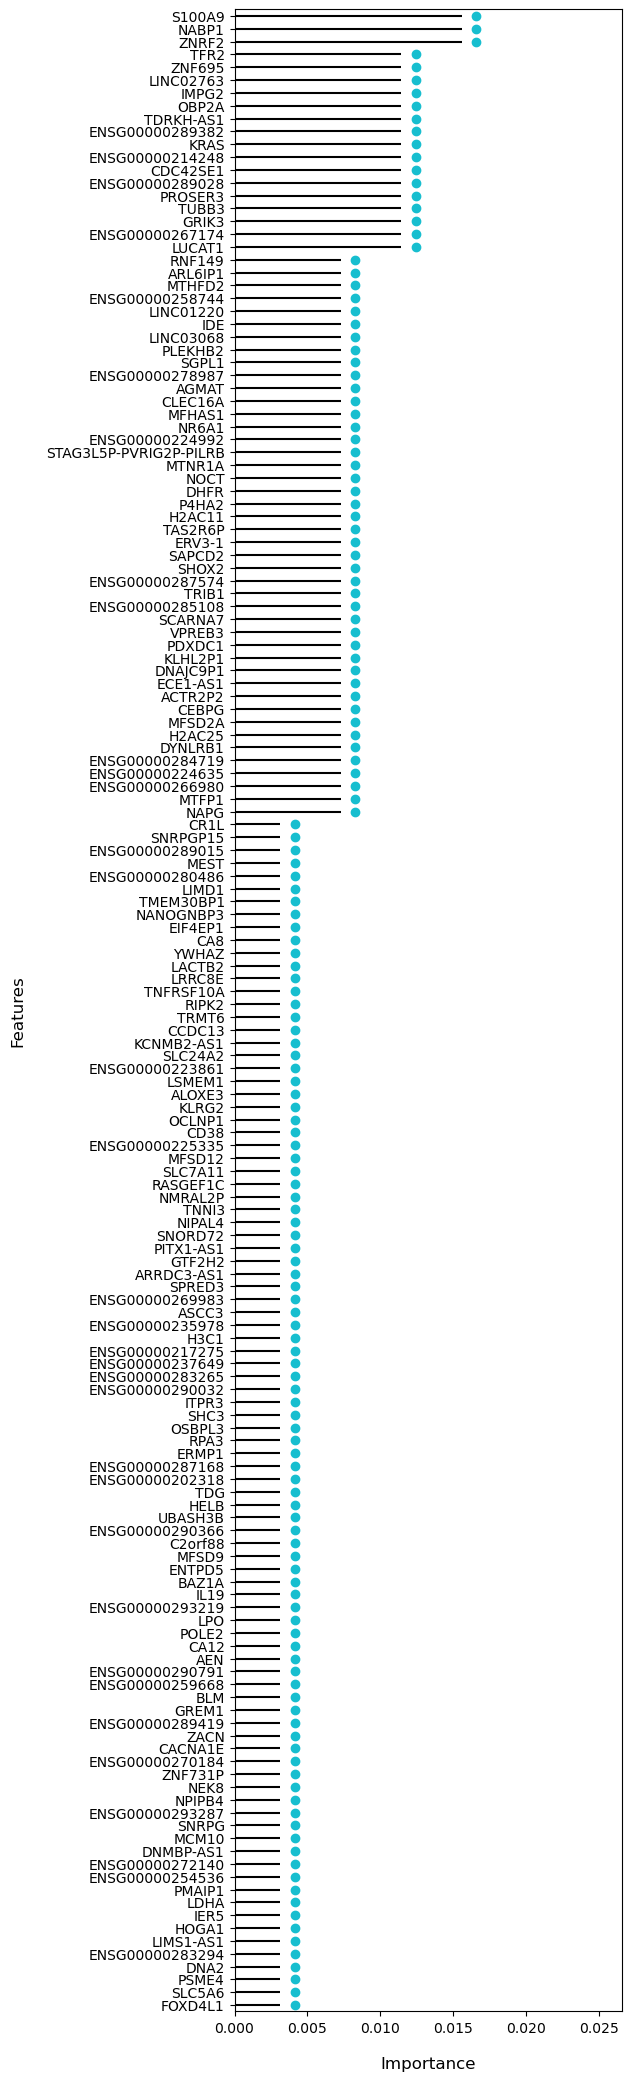

In [84]:
fig, ax = plt.subplots(figsize=(5, 26))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

ax.scatter(x=feature_scores, y=feature_scores.index, color="#17BECF")
miny, nexty, *_, maxy = ax.get_yticks()
eps = (nexty - miny) / 2 
ax.set_ylim(miny-eps, maxy+eps)
ax.set_xlim(0, max(feature_scores+0.01))
for x, y in zip(feature_scores, feature_scores.index):
    plt.hlines(y = y, xmin = 0, xmax = x-0.001, color="black") 
ax.tick_params(axis="both", which="major", labelsize=10)
ax.set_ylabel("Features", fontsize=12, labelpad=15)
ax.set_xlabel("Importance", fontsize=12, labelpad=15)

plt.show()

### Visualise Feature Correlation

In [85]:
rna_cluster_data = X_train_rna_renamed.copy(deep=True)
rna_cluster_corr = rna_cluster_data.corr(numeric_only=True)

In [86]:
rna_cluster_corr

,GJB5,GRIK3,XCL2,TDRD5,ZNF695,CR1L,MKNK1-AS1,UBE2Q1-AS1,ECE1-AS1,FCGR1A,...,CEBPG,CCNP,ENSG00000267174,BCL3,TNNI3,MFSD12,ENSG00000225335,MTFP1,VPREB3,LINC01547
GJB5,1.000000,-0.091933,0.255433,-0.111826,-0.086228,-0.059471,0.062388,0.080956,0.045349,-0.106305,...,0.102031,-0.031989,0.444508,0.410280,0.255689,0.288332,0.201224,0.164209,-0.058678,0.000132
GRIK3,-0.091933,1.000000,0.062473,0.043281,-0.046575,0.086162,0.366516,0.652009,0.055781,-0.040596,...,-0.089301,0.288952,0.212048,0.138521,0.523444,0.439810,0.244373,-0.120940,-0.084118,-0.020962
XCL2,0.255433,0.062473,1.000000,-0.021890,-0.139424,0.832719,-0.040934,-0.032814,-0.014513,0.798666,...,-0.039941,0.060285,0.019398,0.163970,0.229495,0.580044,0.038425,0.477980,0.262180,-0.008912
TDRD5,-0.111826,0.043281,-0.021890,1.000000,0.712115,-0.059875,0.256648,0.006338,0.212192,-0.113562,...,0.257578,0.073041,0.007833,0.193111,0.611817,0.397645,0.318881,0.285485,-0.095394,0.151357
ZNF695,-0.086228,-0.046575,-0.139424,0.712115,1.000000,-0.054205,0.065077,-0.070607,0.225374,-0.122090,...,0.540039,0.226361,-0.075320,-0.083749,0.517554,0.028463,0.200125,0.232371,-0.098567,-0.102213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MFSD12,0.288332,0.439810,0.580044,0.397645,0.028463,0.314402,0.341679,0.445873,0.199237,0.367593,...,-0.033778,0.052037,0.362903,0.633708,0.618277,1.000000,0.541405,0.600928,0.176770,0.300127
ENSG00000225335,0.201224,0.244373,0.038425,0.318881,0.200125,-0.121398,0.282543,0.440460,0.201822,-0.111605,...,0.156377,0.162322,0.697441,0.590071,0.444600,0.541405,1.000000,0.342914,-0.112929,0.093176
MTFP1,0.164209,-0.120940,0.477980,0.285485,0.232371,0.416263,0.132043,0.132188,0.253332,0.327798,...,0.166263,-0.034146,0.141199,0.317890,0.322195,0.600928,0.342914,1.000000,-0.018648,0.498124
VPREB3,-0.058678,-0.084118,0.262180,-0.095394,-0.098567,-0.039719,-0.021496,-0.086855,0.283007,0.688395,...,-0.025871,-0.102719,-0.102610,0.255359,-0.146733,0.176770,-0.112929,-0.018648,1.000000,-0.040601


/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


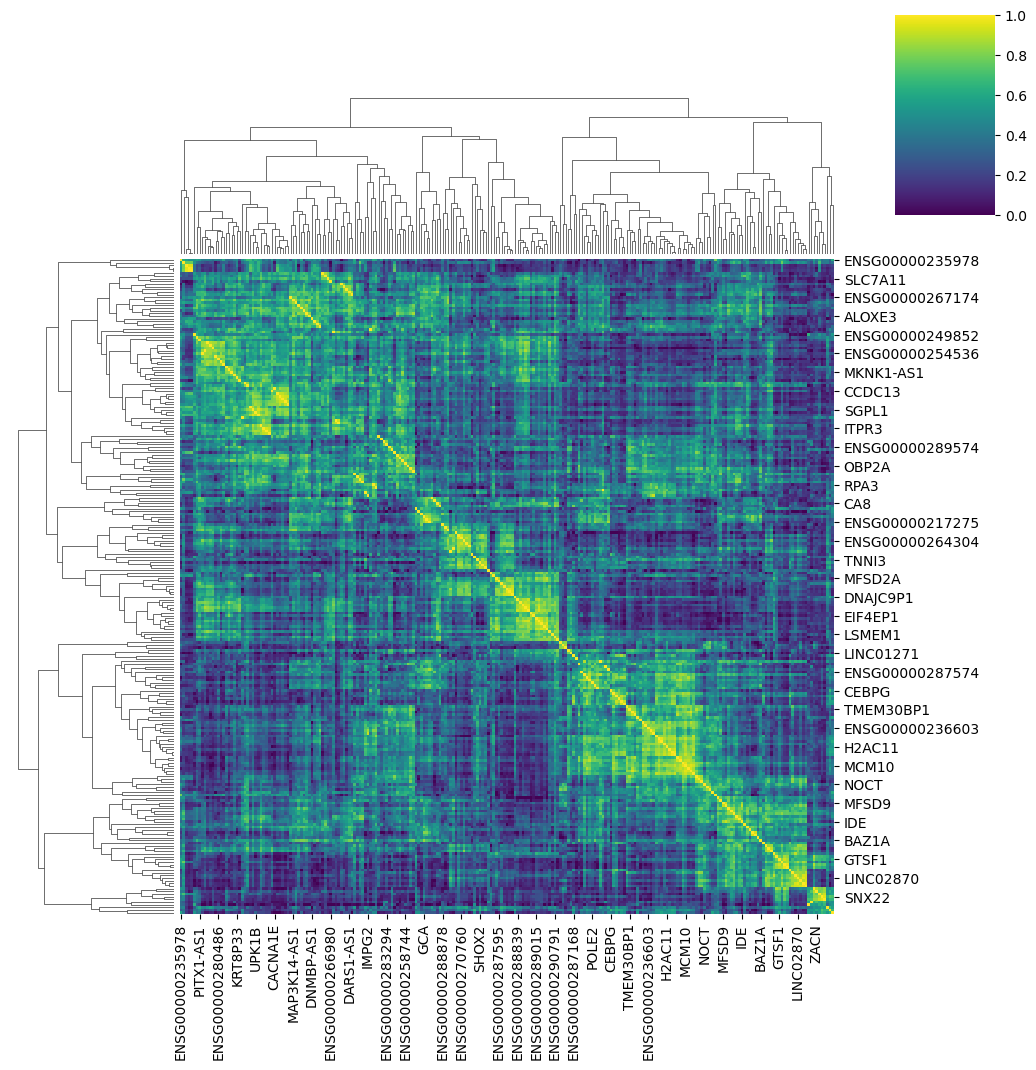

In [87]:
kws = dict(cbar_kws=dict(ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], orientation='vertical'), figsize=(6, 6))

g = sns.clustermap(rna_cluster_corr,
                    metric="correlation", 
                    standard_scale=1, 
                    cmap="viridis", 
                    cbar_pos=(0.9, 0.8, .03, .4)) 

x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.9, 0.86, 0.1, 0.2])
plt.show()

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


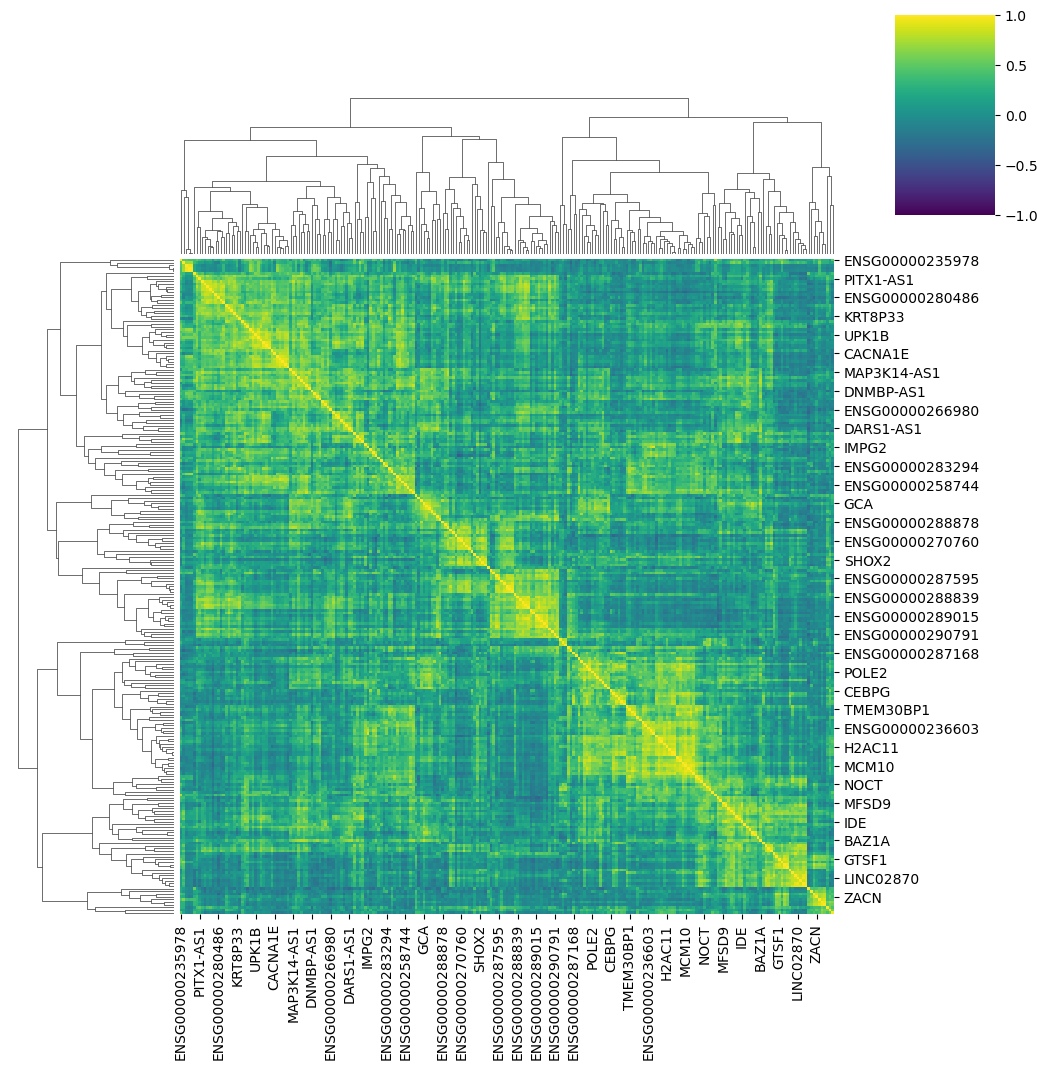

In [90]:
kws = dict(cbar_kws=dict(ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], orientation='vertical'), figsize=(6, 6))

g = sns.clustermap(rna_cluster_corr,
                    metric="correlation", 
                    # standard_scale=1, 
                    cmap="viridis", 
                    cbar_pos=(0.9, 0.8, .03, .4),
                    vmin=-1,
                    vmax=1)

x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.9, 0.86, 0.1, 0.2])
plt.show()

In [91]:
rad_cluster_data = X_train_rad.copy(deep=True)
rad_cluster_corr = rad_cluster_data.corr(numeric_only=True)

In [92]:
rad_cluster_corr

,GLSZM_ZoneHiGl_4gl,GLCM_Varian_8gl,GLCM_Varian_32gl,GLCM_Varian_64gl,GLCM_Varian_256gl,GLSZM_ZoneHiGl_LLL_4gl,NGTDM_Contra_LLL_8gl,GLSZM_SzNonUnif_LLL_32gl,GLSZM_SzVarianc_LLL_32gl,GLSZM_SzNonUnif_LLL_64gl,...,GLSZM_SzVarianc_LLH_32gl,GLSZM_SzNonUnif_LLH_64gl,FD_max_LHL_4gl,FD_max_LHH_4gl,GLSZM_SzVarianc_HHL_8gl,FD_min_HHL_8gl,GLCM_InfCo2_HHL_8gl,GLSZM_SzVarianc_HHH_8gl,FD_min_HHH_8gl,GLCM_InfCo2_HHH_8gl
GLSZM_ZoneHiGl_4gl,1.000000,0.426444,0.457576,0.459065,0.458885,0.963754,0.551489,0.230013,0.441040,0.193488,...,0.441040,0.193488,0.334676,0.334676,0.096985,0.199465,0.729783,0.096985,0.199465,0.729783
GLCM_Varian_8gl,0.426444,1.000000,0.996619,0.996357,0.996439,0.398773,0.880679,0.386489,0.206828,0.487492,...,0.206828,0.487492,0.325231,0.325231,0.025492,0.379850,0.386133,0.025492,0.379850,0.386133
GLCM_Varian_32gl,0.457576,0.996619,1.000000,0.999924,0.999926,0.426435,0.891743,0.409495,0.230573,0.501537,...,0.230573,0.501537,0.344220,0.344220,0.024048,0.383025,0.415310,0.024048,0.383025,0.415310
GLCM_Varian_64gl,0.459065,0.996357,0.999924,1.000000,0.999955,0.428103,0.893668,0.413980,0.234328,0.505360,...,0.234328,0.505360,0.344867,0.344867,0.028109,0.383201,0.415520,0.028109,0.383201,0.415520
GLCM_Varian_256gl,0.458885,0.996439,0.999926,0.999955,1.000000,0.427291,0.893357,0.411405,0.233840,0.503212,...,0.233840,0.503212,0.344038,0.344038,0.029364,0.386287,0.415988,0.029364,0.386287,0.415988
GLSZM_ZoneHiGl_LLL_4gl,0.963754,0.398773,0.426435,0.428103,0.427291,1.000000,0.553354,0.213719,0.409173,0.182055,...,0.409173,0.182055,0.343088,0.343088,0.111728,0.174648,0.702007,0.111728,0.174648,0.702007
NGTDM_Contra_LLL_8gl,0.551489,0.880679,0.891743,0.893668,0.893357,0.553354,1.000000,0.609945,0.489190,0.692718,...,0.489190,0.692718,0.285697,0.285697,0.228282,0.387128,0.591335,0.228282,0.387128,0.591335
GLSZM_SzNonUnif_LLL_32gl,0.230013,0.386489,0.409495,0.413980,0.411405,0.213719,0.609945,1.000000,0.709011,0.948125,...,0.709011,0.948125,0.218174,0.218174,0.539185,0.241447,0.265956,0.539185,0.241447,0.265956
GLSZM_SzVarianc_LLL_32gl,0.441040,0.206828,0.230573,0.234328,0.233840,0.409173,0.489190,0.709011,1.000000,0.768826,...,1.000000,0.768826,0.144470,0.144470,0.604821,0.335415,0.446222,0.604821,0.335415,0.446222
GLSZM_SzNonUnif_LLL_64gl,0.193488,0.487492,0.501537,0.505360,0.503212,0.182055,0.692718,0.948125,0.768826,1.000000,...,0.768826,1.000000,0.158018,0.158018,0.526381,0.281882,0.265947,0.526381,0.281882,0.265947


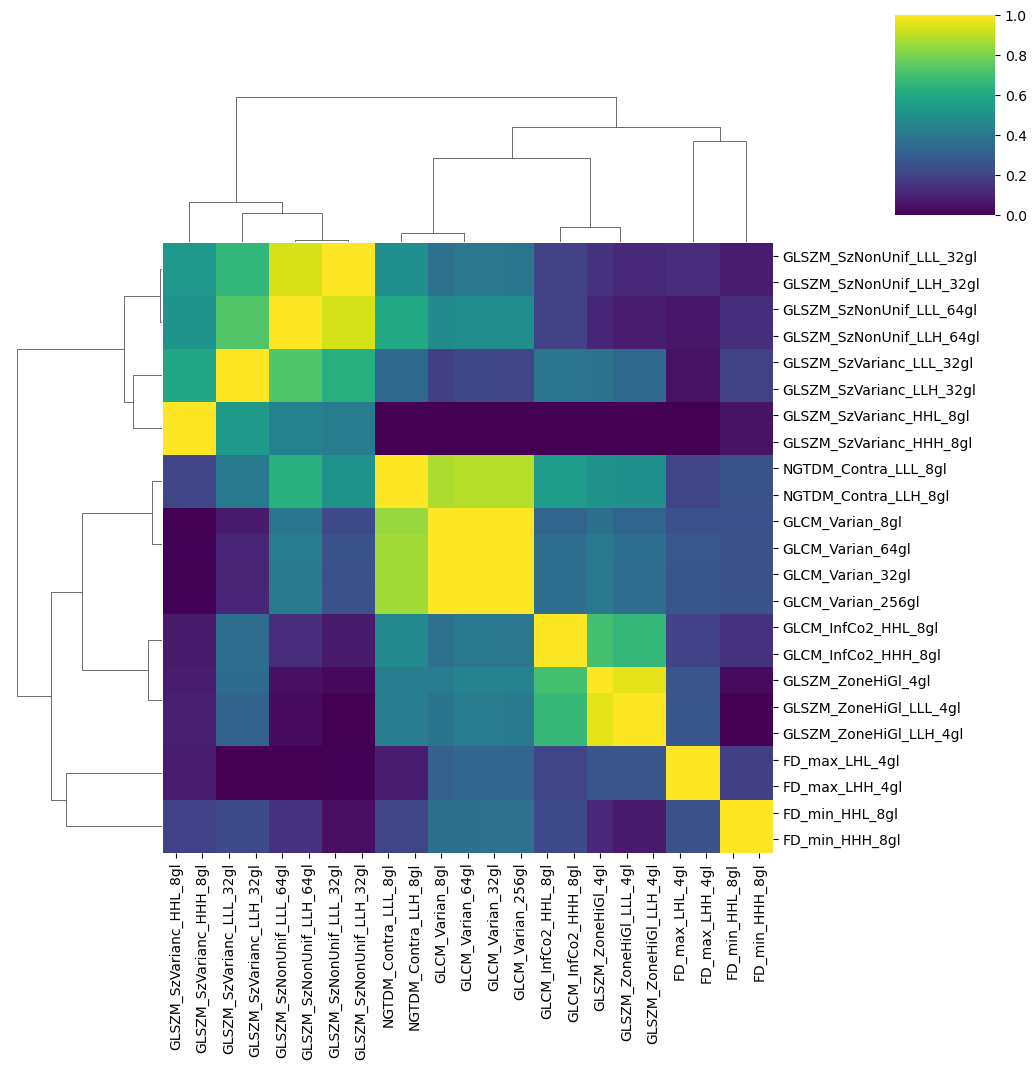

In [93]:
kws = dict(cbar_kws=dict(ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], orientation='vertical'), figsize=(6, 6))

g = sns.clustermap(rad_cluster_corr,
                    metric="correlation", 
                    standard_scale=1, 
                    cmap="viridis", 
                    cbar_pos=(0.9, 0.8, .03, .4)) 

x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([0.9, 0.86, 0.1, 0.2])
plt.show()